<a href="https://colab.research.google.com/github/RafaXzaviero/BENGKEL-KODING/blob/main/HeartFailure2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv ('/content/heart_failure.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40.0,M,ATA,140.0,289.0,0.0,Normal,172.0,N,0.0,Up,0.0
1,49.0,F,NAP,160.0,180.0,0.0,Normal,156.0,N,1.0,Flat,1.0
2,37.0,M,ATA,130.0,283.0,0.0,ST,98.0,N,0.0,Up,0.0
3,48.0,F,ASY,138.0,214.0,0.0,Normal,108.0,Y,1.5,Flat,1.0
4,54.0,M,NAP,150.0,195.0,0.0,Normal,122.0,N,0.0,Up,0.0


In [4]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
1234,29.0,F,ATA,120.0,NaN,1.0,LVH,100.0,Y,2.0,Flat,0.0
1235,70.0,M,NAP,150.0,180.0,1.0,ST,180.0,N,3.0,Flat,0.0
1236,60.0,M,ATA,130.0,300.0,1.0,Normal,160.0,N,1.0,Up,1.0
1237,50.0,M,ASY,120.0,300.0,NaN,ST,140.0,N,1.0,Down,0.0
1238,40.0,F,ATA,140.0,250.0,0.0,ST,140.0,Y,2.0,Flat,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1230 non-null   float64
 1   Sex             1234 non-null   object 
 2   ChestPainType   1232 non-null   object 
 3   RestingBP       1231 non-null   float64
 4   Cholesterol     1229 non-null   float64
 5   FastingBS       1234 non-null   float64
 6   RestingECG      1234 non-null   object 
 7   MaxHR           1233 non-null   float64
 8   ExerciseAngina  1235 non-null   object 
 9   Oldpeak         1233 non-null   float64
 10  ST_Slope        1232 non-null   object 
 11  HeartDisease    1236 non-null   float64
dtypes: float64(7), object(5)
memory usage: 116.3+ KB


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score,
precision_score, recall_score)

In [9]:
df.dropna(inplace=True)

In [10]:
df.drop(df[df['HeartDisease'] == 2].index, inplace=True)

In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [12]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
x = df.drop(['HeartDisease'], axis=1)

y = df['HeartDisease']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

HeartDisease
1.0    490
0.0    440
Name: count, dtype: int64
HeartDisease
1.0    0.526882
0.0    0.473118
Name: proportion, dtype: float64


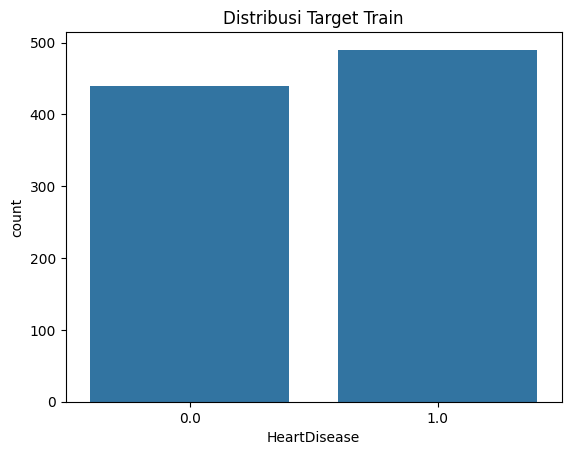

In [17]:
print(y_train.value_counts())

print(y_train.value_counts(normalize=True))
sns.countplot(x=y_train)
plt.title("Distribusi Target Train")
plt.show()

Accuracy 0.7510729613733905
Precision: 0.7580575302899631
Recall: 0.7510729613733905
F1 Score: 0.7525787933471587
Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.76      0.72        97
         1.0       0.81      0.74      0.78       136

    accuracy                           0.75       233
   macro avg       0.75      0.75      0.75       233
weighted avg       0.76      0.75      0.75       233



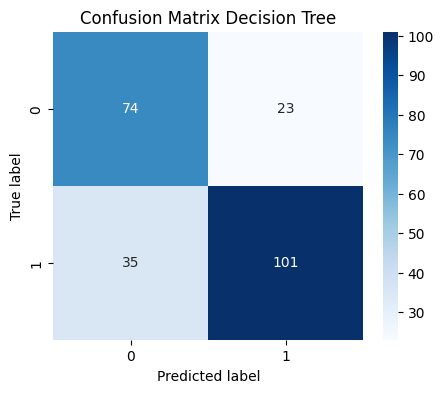

In [19]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

print('Accuracy', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt, average='weighted'))
print('Recall:', recall_score(y_test, y_pred_dt, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred_dt, average='weighted'))
print('Classification Report:\n', classification_report(y_test, y_pred_dt))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.xlabel ("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Decision Tree")
plt.show()

Accuracy 0.6394849785407726
Precision: 0.6394849785407726
Recall: 0.6394849785407726
F1 Score: 0.6394849785407726
Classification Report:
               precision    recall  f1-score   support

         0.0       0.57      0.57      0.57        97
         1.0       0.69      0.69      0.69       136

    accuracy                           0.64       233
   macro avg       0.63      0.63      0.63       233
weighted avg       0.64      0.64      0.64       233



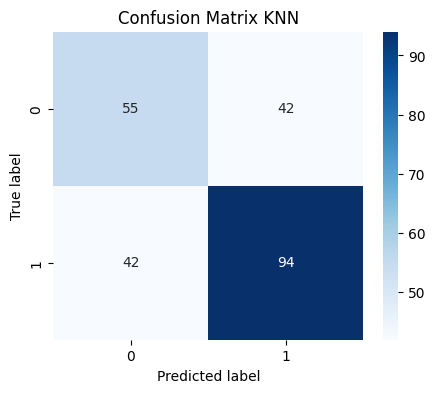

In [21]:
knn_model = KNeighborsClassifier()

knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

print('Accuracy', accuracy_score(y_test, y_pred_knn))
print('Precision:', precision_score(y_test, y_pred_knn, average='weighted'))
print('Recall:', recall_score(y_test, y_pred_knn, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred_knn, average='weighted'))
print('Classification Report:\n', classification_report(y_test, y_pred_knn))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.xlabel ("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix KNN")
plt.show()

In [23]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Accuracy: 0.7510729613733905
Precision: 0.7580575302899631
Recall: 0.7510729613733905
F1 Score: 0.7525787933471587
Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.76      0.72        97
         1.0       0.81      0.74      0.78       136

    accuracy                           0.75       233
   macro avg       0.75      0.75      0.75       233
weighted avg       0.76      0.75      0.75       233



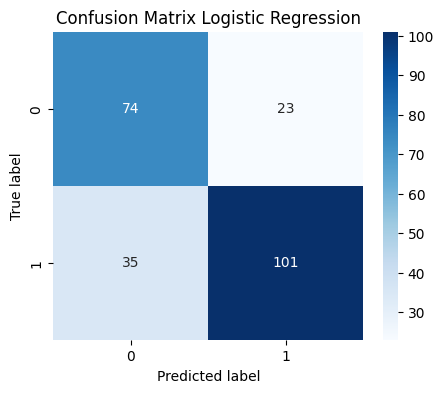

In [25]:
lr_model = LogisticRegression(max_iter=1000, random_state=0)

lr_model.fit(x_train, y_train)

y_pred_lr = dt_model.predict(x_test)

print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Precision:', precision_score(y_test, y_pred_lr, average='weighted'))
print('Recall:', recall_score(y_test, y_pred_lr, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred_lr, average='weighted'))
print('Classification Report:\n', classification_report(y_test, y_pred_lr))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.xlabel ("Predicted label")
plt.ylabel("True label")
plt.title('Confusion Matrix Logistic Regression')
plt.show()